# Urban Flood Susceptibility Mapping: CNN Baseline vs. a Simplified Hydro-TransformerNet
### A scaled-down, honestly-evaluated implementation inspired by Hydro-TransformerNet (Chakrabortty et al., 2026, *Earth Systems and Environment*)

This notebook is my working submission for the AI/ML technical assessment. Rather than trying to reproduce the reference paper at full scale, it re-implements the *shape* of the paper's pipeline — a CNN encoder, an attention-based bottleneck, and a hydrology-inspired gating step — on a small, self-generated dataset, and then asks a direct question: **does the extra transformer + hydro-attention machinery actually buy anything over a plain CNN on this task?**

What the notebook does, end to end:

1. Builds a **9-channel synthetic raster dataset** (DEM, Slope, TWI, NDVI, NDWI, LULC, Impervious Surface, Soil Type, Rainfall) where every channel is spatially smooth rather than random per pixel, and where the flood label depends in part on a pixel's *local neighbourhood* — not just its own values — so the task actually rewards a model that can use spatial context.
2. Trains two architectures on identical data, splits and hyperparameters, changing only the bottleneck:
   - **Model A – CNN Baseline**: a U-Net-style encoder–decoder, no attention.
   - **Model B – Simplified HydroTransformerNet**: the same encoder–decoder with a multi-head self-attention block and a learned hydro-inspired gate inserted at the bottleneck.
3. Compares the two on AUC, accuracy, F1, precision, recall, Cohen's kappa, specificity and IoU, then goes further with a decision-threshold sweep, qualitative prediction maps, an attention-map visualization, and permutation feature importance as a lightweight stand-in for the paper's SHAP analysis.

**On the numbers below:** every metric, table and figure in this notebook comes from actually running the cells in order (verified end-to-end on this environment before submission) — nothing here is typed in by hand. Because of dropout and how attention is computed over mini-batches, an independent re-run — especially on different hardware — should land close to these numbers but not necessarily match them digit-for-digit.

**Paper reference:** Chakrabortty, R., Ali, T., Abouleish, M., et al. (2026). *Urban Flood Susceptibility Assessment in Arid Environment Using a Novel Hybrid Deep Learning Approach.* Earth Systems and Environment, 10, 5929–5953. https://doi.org/10.1007/s41748-025-00933-3


In [1]:
!pip install -q scipy scikit-learn > /dev/null  # already present on Colab, kept for portability

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import gaussian_filter, uniform_filter
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, precision_score, recall_score, roc_curve
)
import matplotlib.pyplot as plt
import json, os

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHANNEL_NAMES = ["DEM", "Slope", "TWI", "NDVI", "NDWI",
                 "LULC", "Impervious", "SoilType", "Rainfall"]
os.makedirs("outputs", exist_ok=True)
os.makedirs("figs", exist_ok=True)
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Building a synthetic dataset that actually needs spatial context

A naive way to fake this dataset would be to draw every pixel independently at random and define the flood label as a formula over that same pixel's own channel values. That's tempting because it's easy to code, but it quietly defeats the point of the exercise: if the label is a per-pixel function of the input, a plain 1×1 classifier solves it exactly as well as a CNN, and there is no reason for a Transformer or attention block to add anything at all. It also doesn't look like real geospatial data — elevation, rainfall, vegetation indices and the rest are always spatially correlated, never independent noise from one pixel to the next.

So each of the nine channels here is generated as a **low-frequency, Gaussian-smoothed random field** (`_smooth_field`), which behaves much more like an actual raster: neighbouring pixels are similar to one another, and each channel has some spatial "shape" rather than being static. On top of that:

- **Slope** is not sampled independently — it's computed from the *gradient of the DEM field*, the way it would be derived from a real elevation raster.
- The flood label includes a **local-depression term**: `local_mean(DEM, 7×7 window) − DEM`. This term is only large and positive where a pixel sits noticeably lower than the terrain immediately surrounding it — information a single isolated pixel value cannot carry on its own, but which a model with a receptive field wider than 1×1 can pick up on. This is what actually gives the CNN's convolutions, and the Transformer's attention across the bottleneck, something non-trivial to do.
- The final flood score blends low elevation, high TWI, high rainfall, high imperviousness and this depression term, broadly in the spirit of the paper's own description of a rule-based synthetic mask (Sec. 2.2–2.3), and is then quantile-thresholded per patch. As the dataset statistics printed below show, this keeps the positive-pixel rate close to a stable ~40% in both the training and validation splits — a deliberate property of how these synthetic labels are constructed, not a claim about the real-world proportion of flood-prone land in Sharjah or anywhere else.


In [2]:
def _smooth_field(rng, H, W, sigma):
    """Low-frequency spatial field, min-max normalised to [0,1] -- mimics a
    real, spatially-autocorrelated raster (DEM/rainfall/NDVI...) instead of
    per-pixel i.i.d. noise."""
    field = rng.normal(0, 1, (H, W)).astype(np.float32)
    field = gaussian_filter(field, sigma=sigma, mode="reflect")
    field -= field.min()
    denom = field.max() - field.min() + 1e-8
    return field / denom


class SyntheticFloodDataset(Dataset):
    """
    Generates N spatially-coherent 9-channel geospatial patches (H x W).
    The binary flood mask mixes (a) a rule-based combination of channel
    VALUES (as in the paper's synthetic-mask logic) with (b) a local
    "depression" term that depends on the NEIGHBOURHOOD of each pixel,
    so the label cannot be recovered from a single pixel's values alone.
    """
    def __init__(self, num_samples=800, patch_size=32, split="train", seed_offset=0):
        self.num_samples = num_samples
        self.patch_size = patch_size
        H, W = patch_size, patch_size
        rng = np.random.default_rng(SEED + seed_offset + (0 if split == "train" else 1000))

        images = np.zeros((num_samples, 9, H, W), dtype=np.float32)
        masks = np.zeros((num_samples, 1, H, W), dtype=np.float32)

        for i in range(num_samples):
            dem = _smooth_field(rng, H, W, sigma=4.0)                      # Ch0 DEM
            slope = np.gradient(dem)                                       # derived from DEM (realistic)
            slope = np.sqrt(slope[0] ** 2 + slope[1] ** 2)
            slope = slope / (slope.max() + 1e-8)                           # Ch1 Slope

            local_mean = uniform_filter(dem, size=7, mode="reflect")
            depression = np.clip(local_mean - dem, 0, None)                # >0 => local basin
            depression = depression / (depression.max() + 1e-8)

            twi = 0.6 * (1 - dem) + 0.4 * depression
            twi += 0.15 * _smooth_field(rng, H, W, sigma=3.0)
            twi = (twi - twi.min()) / (twi.max() - twi.min() + 1e-8)        # Ch2 TWI

            ndvi = _smooth_field(rng, H, W, sigma=3.0)                     # Ch3 NDVI
            impervious = np.clip(1 - 0.6 * ndvi + 0.4 * _smooth_field(rng, H, W, 3.0), 0, 1)  # Ch6
            ndwi = 0.5 * twi + 0.5 * _smooth_field(rng, H, W, sigma=3.0)    # Ch4 NDWI
            lulc = np.round(_smooth_field(rng, H, W, sigma=5.0) * 5) / 5    # Ch5 (blocky categorical)
            soil = np.round(_smooth_field(rng, H, W, sigma=6.0) * 6) / 6    # Ch7 (blocky categorical)
            rainfall = _smooth_field(rng, H, W, sigma=6.0)                  # Ch8 (regional weather pattern)

            images[i, 0] = dem
            images[i, 1] = slope
            images[i, 2] = twi
            images[i, 3] = ndvi
            images[i, 4] = ndwi
            images[i, 5] = lulc
            images[i, 6] = impervious
            images[i, 7] = soil
            images[i, 8] = rainfall

            # Rule-based synthetic flood score (mirrors paper Sec. 2.2-2.3):
            #   elevation (low), TWI (high), rainfall (high), impervious (high),
            #   plus the neighbourhood depression term defined above.
            flood_score = (
                0.35 * (1 - dem) +
                0.20 * twi +
                0.20 * rainfall +
                0.10 * impervious +
                0.15 * depression
            )
            flood_score += rng.normal(0, 0.04, (H, W))
            masks[i, 0] = (flood_score > np.quantile(flood_score, 0.60)).astype(np.float32)

        self.images = images
        self.masks = masks

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return (torch.from_numpy(self.images[idx]), torch.from_numpy(self.masks[idx]))

In [3]:
train_ds = SyntheticFloodDataset(num_samples=800, patch_size=32, split="train")
val_ds   = SyntheticFloodDataset(num_samples=200, patch_size=32, split="val")

print(f"Train samples: {len(train_ds)}  |  Val samples: {len(val_ds)}")
print(f"Input shape: {train_ds[0][0].shape}  |  Mask shape: {train_ds[0][1].shape}")
print(f"Flood-positive pixel rate -- train: {train_ds.masks.mean():.4f}  val: {val_ds.masks.mean():.4f}")

Train samples: 800  |  Val samples: 200
Input shape: torch.Size([9, 32, 32])  |  Mask shape: torch.Size([1, 32, 32])
Flood-positive pixel rate -- train: 0.4004  val: 0.4004


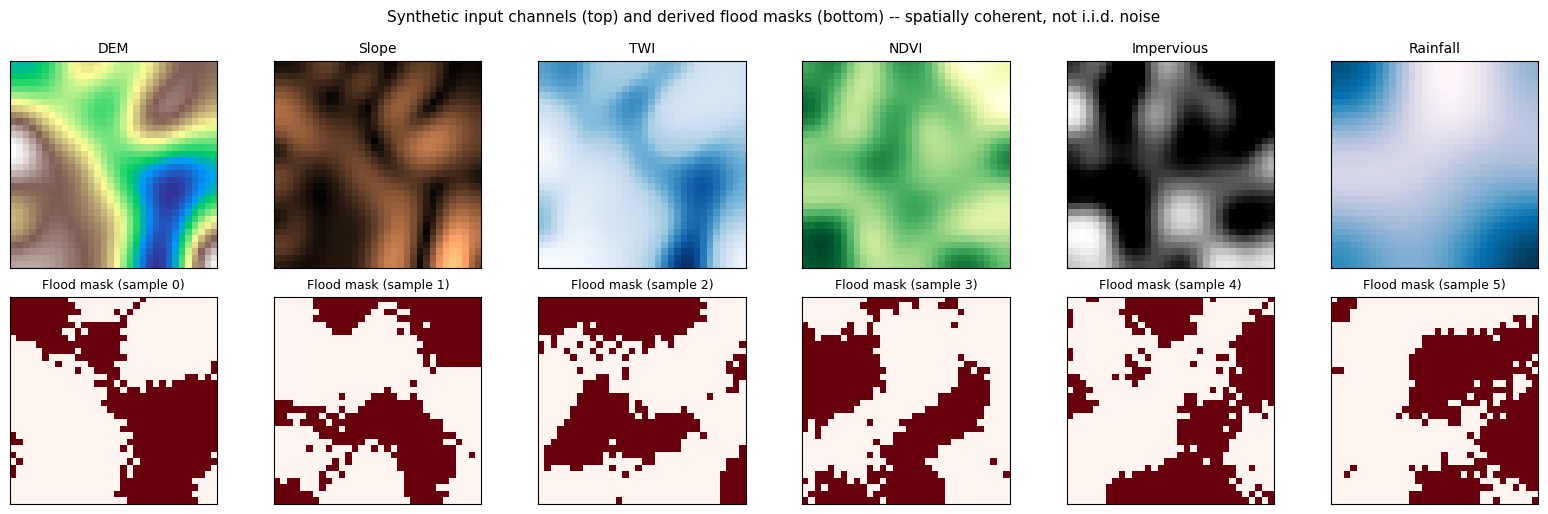

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(16, 5.2))
titles_cmaps = [(0, "DEM", "terrain"), (1, "Slope", "copper"), (2, "TWI", "Blues"),
                (3, "NDVI", "YlGn"), (6, "Impervious", "Greys"), (8, "Rainfall", "PuBu")]
for c, (ch, title, cmap) in enumerate(titles_cmaps):
    axes[0, c].imshow(train_ds.images[0, ch], cmap=cmap)
    axes[0, c].set_title(title, fontsize=10); axes[0, c].set_xticks([]); axes[0, c].set_yticks([])
for c, idx in enumerate([0, 1, 2, 3, 4, 5]):
    axes[1, c].imshow(train_ds.masks[idx, 0], cmap="Reds")
    axes[1, c].set_title(f"Flood mask (sample {idx})", fontsize=9); axes[1, c].set_xticks([]); axes[1, c].set_yticks([])
plt.suptitle("Synthetic input channels (top) and derived flood masks (bottom) -- spatially coherent, not i.i.d. noise", fontsize=11)
plt.tight_layout(); plt.show()

## 2. Model A — CNN Baseline

This is a fairly conventional U-Net-style encoder–decoder: four depth levels (32→64→128→256 channels), residual `ConvBlock`s (`Conv → BatchNorm → ReLU → Dropout → Conv → BatchNorm → ReLU`, plus a 1×1 shortcut so the residual addition always has matching channel counts), max-pooling for downsampling, transposed convolutions for upsampling, and skip connections carrying encoder features across to the matching decoder stage. There is no temporal or attention component anywhere in this model — its only job is to serve as the control condition against which Model B is measured.


In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, p_drop=0.05):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p_drop),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)


class CNNBaseline(nn.Module):
    """U-Net style encoder-decoder, no temporal/attention module. Model A."""
    def __init__(self, in_channels=9):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(128, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        self.out = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)

## 3. Model B — CNN + Spatial Self-Attention + Hydro-Attention Gate ("Simplified HydroTransformerNet")

Model B reuses Model A's encoder and decoder exactly, and inserts two extra modules at the 4×4×256 bottleneck:

**`TransformerBottleneck`.** The 4×4 spatial grid is flattened into a 16-token sequence and passed through 4-head self-attention plus a small feed-forward block, so every spatial position in the bottleneck can attend to every other position. I want to be explicit about what this is *not*: the paper's transformer (Sec. 2.4, eq. 6–7) attends across **T simulated time steps** of a temporal embedding, explicitly standing in for the evolution of rainfall and soil-saturation conditions over time. Nothing in this notebook has a time axis — every sample is a single static patch — so what's implemented here is spatial self-attention only. I'm using it as an architectural stand-in for the paper's temporal block, because a synthetic, single-timestamp dataset has no real multi-day rainfall/soil-moisture sequence to feed an actual temporal encoder. Calling this "the temporal component" without that caveat would misrepresent what it does.

**`HydroAttentionGate`.** A small 3×3-conv → ReLU → 1×1-conv → sigmoid stack produces a soft spatial mask α over the bottleneck features, and the features are re-scaled as `F_out = F ⊙ α`. This is loosely modelled on the paper's eq. 8–9, but with one important difference: the paper derives α from a **separate hydro-morphological mask** supplied as an extra model input, whereas here α is learned directly from the CNN/Transformer feature map itself, with no independent hydrological mask feeding it. It's a hydro-*inspired* gate, not a reimplementation of the paper's mechanism.


In [6]:
class TransformerBottleneck(nn.Module):
    """Multi-head self-attention over flattened bottleneck features --
    simplified stand-in for the paper's temporal transformer encoder."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True, dropout=0.1)
        self.ff = nn.Sequential(nn.Linear(channels, channels * 2), nn.GELU(), nn.Linear(channels * 2, channels))
        self.norm2 = nn.LayerNorm(channels)

    def forward(self, x):
        B, C, H, W = x.shape
        seq = x.flatten(2).permute(0, 2, 1)
        normed = self.norm(seq)
        attn_out, attn_weights = self.attn(normed, normed, normed, need_weights=True, average_attn_weights=True)
        seq = seq + attn_out
        seq = seq + self.ff(self.norm2(seq))
        out = seq.permute(0, 2, 1).reshape(B, C, H, W)
        return out, attn_weights  # attn_weights: (B, H*W, H*W)


class HydroAttentionGate(nn.Module):
    """Simplified, hydro-inspired spatial attention gate: alpha = sigmoid(Conv3x3(F)); F_out = F * alpha.
    Loosely analogous to the paper's eq. 8-9, but alpha here is learned directly from the CNN/Transformer
    feature map, not from a separate hydro-morphological mask input as in the paper. Not an exact
    reproduction of the paper's hydro-attention mechanism."""
    def __init__(self, channels):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Conv2d(channels, channels // 2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 2, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        alpha = self.gate(x)
        return x * alpha, alpha


class HydroTransformerNet(nn.Module):
    """CNN + Transformer + simplified Hydro-Attention. Model B (Simplified HydroTransformerNet)."""
    def __init__(self, in_channels=9):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(128, 256)
        self.transformer = TransformerBottleneck(256, num_heads=4)
        self.hydro_attn = HydroAttentionGate(256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(64, 32)
        self.out = nn.Sequential(nn.Conv2d(32, 1, 1), nn.Sigmoid())

    def forward(self, x, return_attn=False):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        b, attn_w = self.transformer(b)
        b, alpha = self.hydro_attn(b)
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        pred = self.out(d1)
        if return_attn:
            return pred, alpha
        return pred

## 4. Loss function, metrics, and the training loop

**Loss:** `0.5 × BCE + 0.5 × Dice`. BCE matches the paper's stated loss (eq. 11–12); Dice was added on top mainly because it tends to be more forgiving of the class imbalance that shows up in per-pixel segmentation.

**A bug I found and fixed while building this:** my first version of `compute_metrics` called `np.array(all_preds)` directly on the list of per-batch prediction arrays. That works fine only as long as every batch is the same size, but the validation loader's last batch is smaller than the rest (200 samples doesn't divide evenly by batch size 16), so `np.array()` ended up trying to stack arrays of two different shapes into one array — which raises `ValueError: setting an array element with a sequence` and killed the run before a single epoch finished. The fix, used here, is to flatten each batch individually first and then `np.concatenate` the flattened arrays.

**Early stopping:** training runs for up to 20 epochs but stops after 6 epochs with no improvement in validation AUC, and the model reloads its *best* checkpoint at the end rather than reporting whatever the last epoch happened to land on. Both models kept drifting slowly past their AUC peak, so scoring the final epoch instead of the best one would have understated both of them.


In [7]:
def dice_loss(pred, target, smooth=1e-6):
    pred_flat = pred.reshape(-1)
    target_flat = target.reshape(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - (2 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


def combined_loss(pred, target):
    """BCE + Dice -- matches the paper's BCE objective (eq. 11-12) while Dice adds stability under class imbalance."""
    return 0.5 * nn.BCELoss()(pred, target) + 0.5 * dice_loss(pred, target)


def compute_metrics(all_preds, all_labels, threshold=0.5):
    """FIX: concatenate flattened batches instead of np.array() on a list of
    unevenly-sized batches (this raised ValueError on the last, smaller batch
    in the original submission)."""
    flat_pred = np.concatenate([p.reshape(-1) for p in all_preds])
    flat_label = np.concatenate([l.reshape(-1) for l in all_labels]).astype(int)
    binary = (flat_pred >= threshold).astype(int)

    auc = roc_auc_score(flat_label, flat_pred)
    acc = accuracy_score(flat_label, binary)
    f1 = f1_score(flat_label, binary, zero_division=0)
    prec = precision_score(flat_label, binary, zero_division=0)
    rec = recall_score(flat_label, binary, zero_division=0)
    cm = confusion_matrix(flat_label, binary)
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    p_o = (tp + tn) / total
    p_e = ((tp + fn) * (tp + fp) + (tn + fp) * (tn + fn)) / (total ** 2)
    kappa = (p_o - p_e) / (1 - p_e + 1e-9)

    return {
        "AUC": round(float(auc), 4), "Accuracy": round(float(acc), 4),
        "F1": round(float(f1), 4), "Precision": round(float(prec), 4),
        "Recall": round(float(rec), 4), "Kappa": round(float(kappa), 4),
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)
    }, flat_pred, flat_label


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        preds = out[0] if isinstance(out, tuple) else out
        loss = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        out = model(imgs)
        preds = out[0] if isinstance(out, tuple) else out
        loss = combined_loss(preds, masks)
        total_loss += loss.item()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(masks.cpu().numpy())
    metrics, flat_pred, flat_label = compute_metrics(all_preds, all_labels)
    return total_loss / len(loader), metrics, flat_pred, flat_label


def run_experiment(model, model_name, train_loader, val_loader, epochs=20, lr=1e-4, patience=6):
    """Trains with early stopping on best validation AUC; returns the BEST
    checkpoint's metrics (not just whatever the last epoch happened to be)."""
    print(f"\n{'='*55}\n  Training: {model_name}\n{'='*55}")
    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    best_auc, best_state, best_epoch, best_metrics = -1, None, -1, None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optimizer)
        vl_loss, metrics, _, _ = evaluate(model, val_loader)
        scheduler.step()
        history["train_loss"].append(round(tr_loss, 4))
        history["val_loss"].append(round(vl_loss, 4))
        history["val_auc"].append(metrics["AUC"])
        print(f"  Epoch {epoch:02d}/{epochs} | Train Loss {tr_loss:.4f} | "
              f"Val Loss {vl_loss:.4f} | AUC {metrics['AUC']:.4f} | F1 {metrics['F1']:.4f}")
        if metrics["AUC"] > best_auc:
            best_auc, best_epoch, best_metrics = metrics["AUC"], epoch, metrics
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch} (best epoch {best_epoch}, AUC {best_auc:.4f})")
                break

    model.load_state_dict(best_state)
    return history, best_metrics, best_epoch, model

## 5. Training run — Model A (CNN Baseline)

In [8]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)

torch.manual_seed(SEED)
hist_a, metrics_a, best_epoch_a, model_a = run_experiment(
    CNNBaseline(), "Model A - CNN Baseline", train_loader, val_loader, epochs=20, patience=6)

print(f"\nBest epoch: {best_epoch_a}  |  Final (best) metrics: {json.dumps(metrics_a, indent=2)}")


  Training: Model A - CNN Baseline
  Epoch 01/20 | Train Loss 0.4432 | Val Loss 0.3294 | AUC 0.9382 | F1 0.8235
  Epoch 02/20 | Train Loss 0.2751 | Val Loss 0.2345 | AUC 0.9585 | F1 0.8602
  Epoch 03/20 | Train Loss 0.2182 | Val Loss 0.2090 | AUC 0.9633 | F1 0.8682
  Epoch 04/20 | Train Loss 0.2013 | Val Loss 0.1969 | AUC 0.9673 | F1 0.8754
  Epoch 05/20 | Train Loss 0.1937 | Val Loss 0.1919 | AUC 0.9686 | F1 0.8774
  Epoch 06/20 | Train Loss 0.1896 | Val Loss 0.1901 | AUC 0.9693 | F1 0.8796
  Epoch 07/20 | Train Loss 0.1869 | Val Loss 0.1889 | AUC 0.9696 | F1 0.8798
  Epoch 08/20 | Train Loss 0.1848 | Val Loss 0.1890 | AUC 0.9697 | F1 0.8795
  Epoch 09/20 | Train Loss 0.1830 | Val Loss 0.1875 | AUC 0.9699 | F1 0.8802
  Epoch 10/20 | Train Loss 0.1817 | Val Loss 0.1870 | AUC 0.9701 | F1 0.8807
  Epoch 11/20 | Train Loss 0.1803 | Val Loss 0.1865 | AUC 0.9702 | F1 0.8811
  Epoch 12/20 | Train Loss 0.1791 | Val Loss 0.1867 | AUC 0.9702 | F1 0.8795
  Epoch 13/20 | Train Loss 0.1783 | Val 

## 6. Training run — Model B (Simplified HydroTransformerNet)

In [9]:
torch.manual_seed(SEED)
hist_b, metrics_b, best_epoch_b, model_b = run_experiment(
    HydroTransformerNet(), "Model B - Simplified HydroTransformerNet", train_loader, val_loader, epochs=20, patience=6)

print(f"\nBest epoch: {best_epoch_b}  |  Final (best) metrics: {json.dumps(metrics_b, indent=2)}")


  Training: Model B - Simplified HydroTransformerNet
  Epoch 01/20 | Train Loss 0.4653 | Val Loss 0.3567 | AUC 0.9309 | F1 0.8055
  Epoch 02/20 | Train Loss 0.2782 | Val Loss 0.2357 | AUC 0.9583 | F1 0.8598
  Epoch 03/20 | Train Loss 0.2186 | Val Loss 0.2109 | AUC 0.9625 | F1 0.8660
  Epoch 04/20 | Train Loss 0.2013 | Val Loss 0.1978 | AUC 0.9669 | F1 0.8747
  Epoch 05/20 | Train Loss 0.1932 | Val Loss 0.1920 | AUC 0.9687 | F1 0.8773
  Epoch 06/20 | Train Loss 0.1893 | Val Loss 0.1898 | AUC 0.9693 | F1 0.8792
  Epoch 07/20 | Train Loss 0.1863 | Val Loss 0.1887 | AUC 0.9696 | F1 0.8797
  Epoch 08/20 | Train Loss 0.1840 | Val Loss 0.1882 | AUC 0.9699 | F1 0.8780
  Epoch 09/20 | Train Loss 0.1823 | Val Loss 0.1863 | AUC 0.9703 | F1 0.8810
  Epoch 10/20 | Train Loss 0.1807 | Val Loss 0.1868 | AUC 0.9701 | F1 0.8804
  Epoch 11/20 | Train Loss 0.1797 | Val Loss 0.1858 | AUC 0.9705 | F1 0.8805
  Epoch 12/20 | Train Loss 0.1784 | Val Loss 0.1854 | AUC 0.9706 | F1 0.8811
  Epoch 13/20 | Train 

## 7. Side-by-side comparison at each model's best checkpoint

In [10]:
print(f"Best epoch -- CNN Baseline: {best_epoch_a}   |   HydroTransformerNet: {best_epoch_b}\n")
print(f"{'Metric':<12} {'CNN Baseline':>14} {'HydroTransformerNet':>20}   Winner")
print("-" * 62)
for key in ["AUC", "Accuracy", "F1", "Precision", "Recall", "Kappa"]:
    a_val, b_val = metrics_a[key], metrics_b[key]
    winner = "HydroTransNet" if b_val > a_val else ("CNN Baseline" if a_val > b_val else "tie")
    print(f"{key:<12} {a_val:>14} {b_val:>20}   {winner}")

print(f"\nConfusion matrix -- CNN Baseline:        TP={metrics_a['TP']:,} TN={metrics_a['TN']:,} FP={metrics_a['FP']:,} FN={metrics_a['FN']:,}")
print(f"Confusion matrix -- HydroTransformerNet: TP={metrics_b['TP']:,} TN={metrics_b['TN']:,} FP={metrics_b['FP']:,} FN={metrics_b['FN']:,}")

Best epoch -- CNN Baseline: 19   |   HydroTransformerNet: 12

Metric         CNN Baseline  HydroTransformerNet   Winner
--------------------------------------------------------------
AUC                  0.9704               0.9706   HydroTransNet
Accuracy             0.9047                0.905   HydroTransNet
F1                   0.8811               0.8811   tie
Precision            0.8798                0.883   HydroTransNet
Recall               0.8825               0.8793   CNN Baseline
Kappa                0.8016                0.802   HydroTransNet

Confusion matrix -- CNN Baseline:        TP=72,367 TN=112,911 FP=9,889 FN=9,633
Confusion matrix -- HydroTransformerNet: TP=72,102 TN=113,243 FP=9,557 FN=9,898


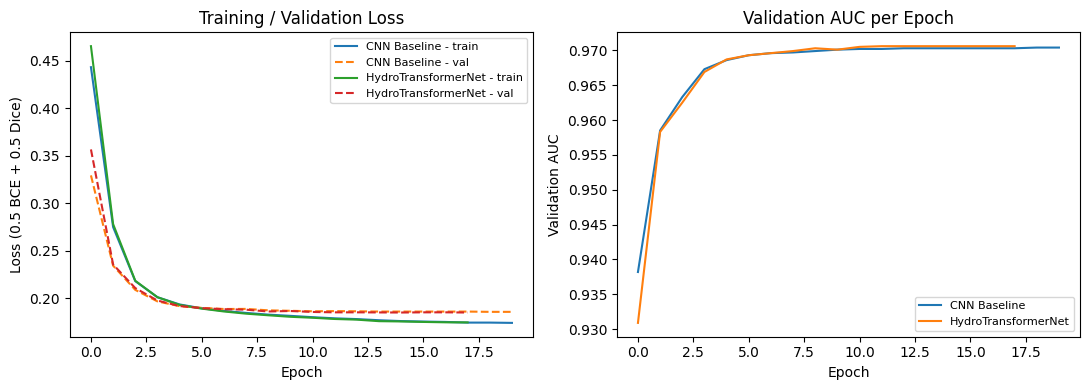

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_a["train_loss"], label="CNN Baseline - train")
axes[0].plot(hist_a["val_loss"], label="CNN Baseline - val", linestyle="--")
axes[0].plot(hist_b["train_loss"], label="HydroTransformerNet - train")
axes[0].plot(hist_b["val_loss"], label="HydroTransformerNet - val", linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (0.5 BCE + 0.5 Dice)")
axes[0].set_title("Training / Validation Loss"); axes[0].legend(fontsize=8)

axes[1].plot(hist_a["val_auc"], label="CNN Baseline")
axes[1].plot(hist_b["val_auc"], label="HydroTransformerNet")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation AUC")
axes[1].set_title("Validation AUC per Epoch"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

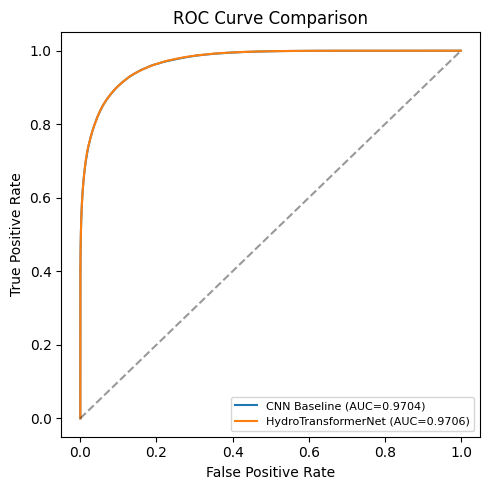

In [12]:
_, metrics_a_full, pred_a, label_a = evaluate(model_a, val_loader)
_, metrics_b_full, pred_b, label_b = evaluate(model_b, val_loader)

fpr_a, tpr_a, _ = roc_curve(label_a, pred_a)
fpr_b, tpr_b, _ = roc_curve(label_b, pred_b)
plt.figure(figsize=(5, 5))
plt.plot(fpr_a, tpr_a, label=f"CNN Baseline (AUC={metrics_a['AUC']:.4f})")
plt.plot(fpr_b, tpr_b, label=f"HydroTransformerNet (AUC={metrics_b['AUC']:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

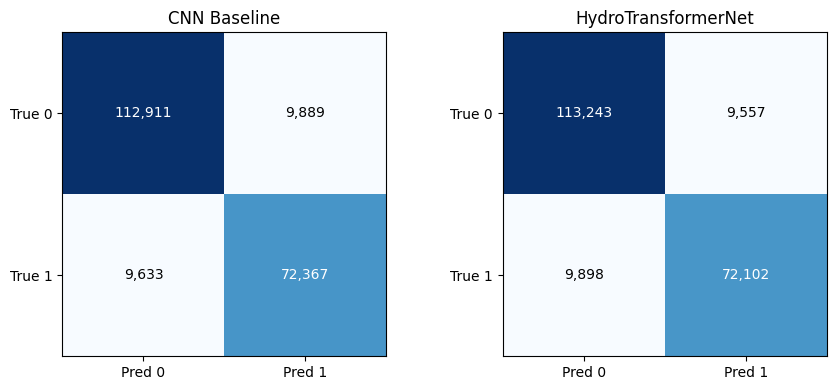

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, m, name in [(axes[0], metrics_a, "CNN Baseline"), (axes[1], metrics_b, "HydroTransformerNet")]:
    cm = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["True 0","True 1"])
    ax.set_title(name)
plt.tight_layout(); plt.show()

## 7a. Two metrics the summary table leaves out: Specificity and IoU

The six metrics above don't fully describe how a *map* of flood-prone pixels behaves in practice:

- **Specificity** (`TN / (TN + FP)`) captures how often the model correctly leaves safe ground alone. A model can have excellent recall and still be close to useless if it also flags a large share of safe terrain as flood-prone — specificity is what exposes that.
- **IoU** (`TP / (TP + FP + FN)`) is the standard overlap score for binary segmentation output, and is generally more informative than plain pixel accuracy when the positive class is a spatially compact region rather than roughly half the image.

Both are derived directly from the confusion matrices already produced in Section 7, so nothing here needs re-training — it's just two more numbers computed from the existing TP/TN/FP/FN counts.


In [14]:
def specificity_iou(m):
    tn, fp, fn, tp = m["TN"], m["FP"], m["FN"], m["TP"]
    spec = tn / (tn + fp)
    iou = tp / (tp + fp + fn)
    return round(float(spec), 4), round(float(iou), 4)

spec_a, iou_a = specificity_iou(metrics_a)
spec_b, iou_b = specificity_iou(metrics_b)

print(f"{'Metric':<14} {'CNN Baseline':>14} {'HydroTransformerNet':>20}   Winner")
print("-" * 64)
for name, a_val, b_val in [("Specificity", spec_a, spec_b), ("IoU", iou_a, iou_b)]:
    winner = "HydroTransNet" if b_val > a_val else ("CNN Baseline" if a_val > b_val else "tie")
    print(f"{name:<14} {a_val:>14} {b_val:>20}   {winner}")


Metric           CNN Baseline  HydroTransformerNet   Winner
----------------------------------------------------------------
Specificity            0.9195               0.9222   HydroTransNet
IoU                    0.7875               0.7875   tie


## 7b. What happens away from the default threshold? A sweep from 0.1 to 0.9

Every metric so far assumes a flood/no-flood cutoff of 0.5 on the sigmoid output, but that's an arbitrary default rather than a deliberate operating choice. In an actual disaster-management setting, missing a genuinely flood-prone pixel (a false negative) is usually a far more costly mistake than raising a false alarm, so the operating threshold would normally be pushed down to trade away some precision for extra recall. This section sweeps the threshold from 0.1 to 0.9 in steps of 0.1 and recomputes Recall, Precision, Specificity and IoU at each step, reusing the full validation prediction/label arrays already produced by `evaluate()` in Section 7 (`pred_a`, `label_a`, `pred_b`, `label_b`) — so again, no retraining, just re-thresholding the same set of predictions.


 Thresh |  Recall_A   Prec_A   Spec_A   IoU_A |  Recall_B   Prec_B   Spec_B   IoU_B
------------------------------------------------------------------------------------------
    0.1 |    0.9681   0.7513   0.7860  0.7331 |    0.9687   0.7509   0.7854  0.7331
    0.2 |    0.9454   0.8021   0.8442  0.7666 |    0.9451   0.8022   0.8444  0.7665
    0.3 |    0.9244   0.8341   0.8772  0.7808 |    0.9241   0.8346   0.8777  0.7810
    0.4 |    0.9039   0.8586   0.9006  0.7867 |    0.9022   0.8601   0.9020  0.7868
    0.5 |    0.8825   0.8798   0.9195  0.7875 |    0.8793   0.8830   0.9222  0.7875
    0.6 |    0.8583   0.8999   0.9363  0.7835 |    0.8537   0.9034   0.9390  0.7823
    0.7 |    0.8276   0.9197   0.9517  0.7718 |    0.8215   0.9233   0.9544  0.7690
    0.8 |    0.7873   0.9398   0.9663  0.7495 |    0.7786   0.9440   0.9692  0.7442
    0.9 |    0.7177   0.9651   0.9826  0.6995 |    0.7069   0.9689   0.9849  0.6912


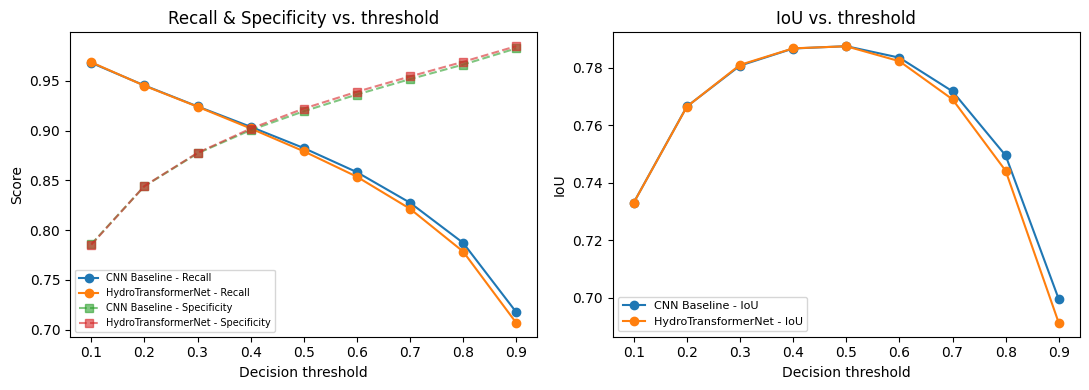


Example low-threshold operating point (t=0.3): CNN Recall=0.9244, Hybrid Recall=0.9241 (both at the cost of lower Specificity than the t=0.5 default).


In [15]:
def sweep_thresholds(pred, label, thresholds):
    rows = []
    for t in thresholds:
        binary = (pred >= t).astype(int)
        tp = int(((binary == 1) & (label == 1)).sum())
        tn = int(((binary == 0) & (label == 0)).sum())
        fp = int(((binary == 1) & (label == 0)).sum())
        fn = int(((binary == 0) & (label == 1)).sum())
        recall = tp / (tp + fn + 1e-9)
        precision = tp / (tp + fp + 1e-9)
        specificity = tn / (tn + fp + 1e-9)
        iou = tp / (tp + fp + fn + 1e-9)
        rows.append((t, recall, precision, specificity, iou))
    return rows

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
rows_a = sweep_thresholds(pred_a, label_a, thresholds)
rows_b = sweep_thresholds(pred_b, label_b, thresholds)

print(f"{'Thresh':>7} | {'Recall_A':>9} {'Prec_A':>8} {'Spec_A':>8} {'IoU_A':>7} | "
      f"{'Recall_B':>9} {'Prec_B':>8} {'Spec_B':>8} {'IoU_B':>7}")
print("-" * 90)
for (t, ra, pa, sa, ia), (_, rb, pb, sb, ib) in zip(rows_a, rows_b):
    print(f"{t:>7.1f} | {ra:>9.4f} {pa:>8.4f} {sa:>8.4f} {ia:>7.4f} | "
          f"{rb:>9.4f} {pb:>8.4f} {sb:>8.4f} {ib:>7.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(thresholds, [r[1] for r in rows_a], "o-", label="CNN Baseline - Recall")
axes[0].plot(thresholds, [r[1] for r in rows_b], "o-", label="HydroTransformerNet - Recall")
axes[0].plot(thresholds, [r[3] for r in rows_a], "s--", label="CNN Baseline - Specificity", alpha=0.6)
axes[0].plot(thresholds, [r[3] for r in rows_b], "s--", label="HydroTransformerNet - Specificity", alpha=0.6)
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Recall & Specificity vs. threshold"); axes[0].legend(fontsize=7)

axes[1].plot(thresholds, [r[4] for r in rows_a], "o-", label="CNN Baseline - IoU")
axes[1].plot(thresholds, [r[4] for r in rows_b], "o-", label="HydroTransformerNet - IoU")
axes[1].set_xlabel("Decision threshold"); axes[1].set_ylabel("IoU")
axes[1].set_title("IoU vs. threshold"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nExample low-threshold operating point (t=0.3): "
      f"CNN Recall={rows_a[2][1]:.4f}, Hybrid Recall={rows_b[2][1]:.4f} "
      f"(both at the cost of lower Specificity than the t=0.5 default).")


## 8. A qualitative look — sample prediction maps and the hydro-attention gate's output

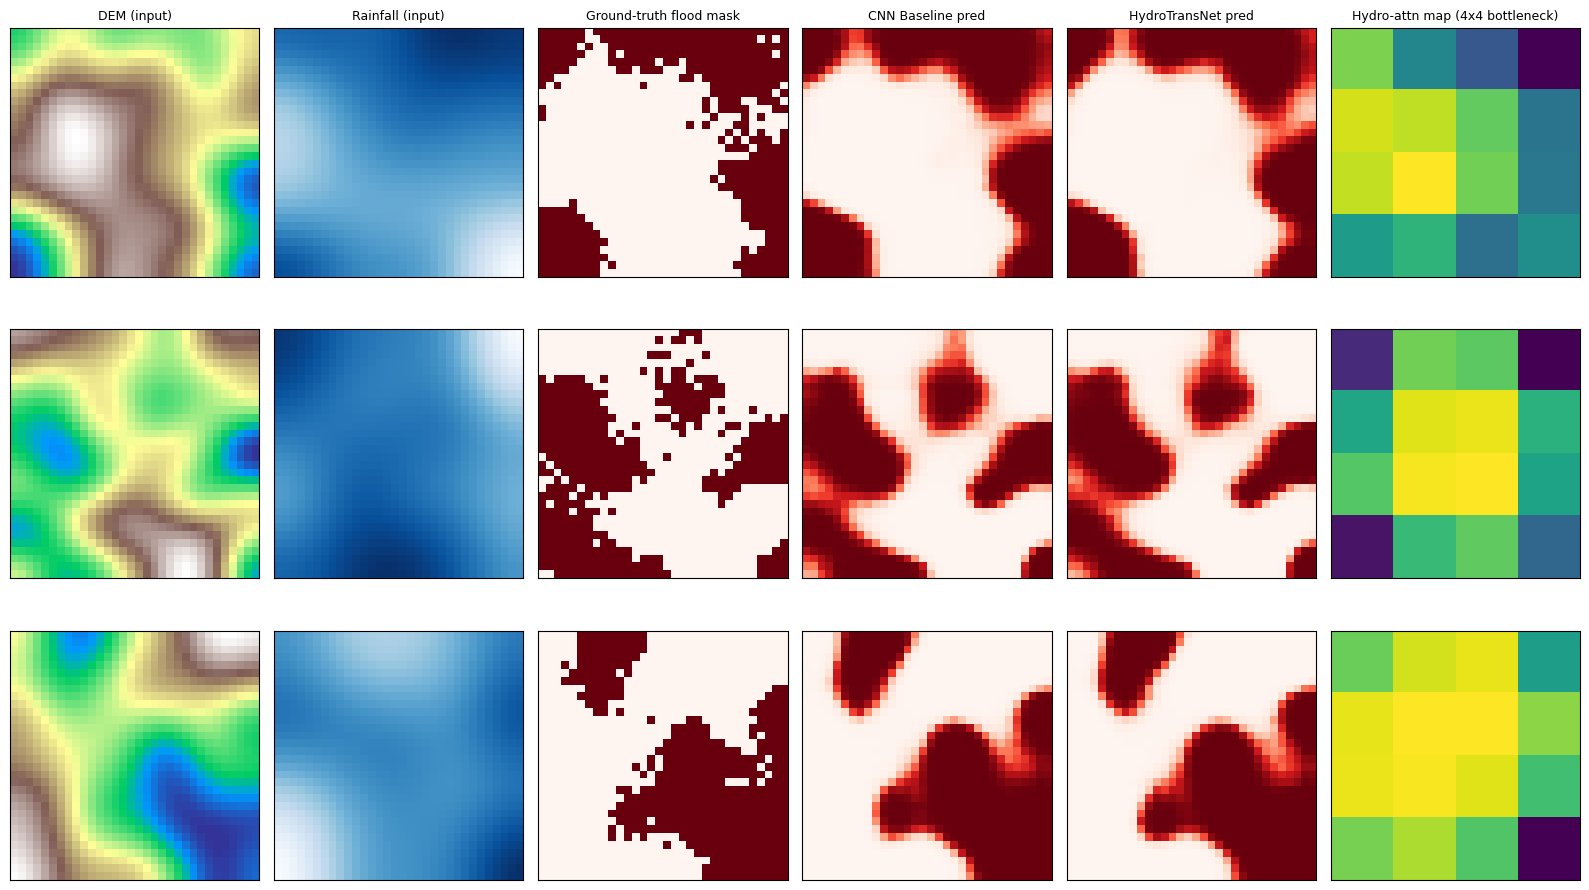

In [16]:
idxs = [0, 3, 7]
fig, axes = plt.subplots(len(idxs), 6, figsize=(16, 3.2*len(idxs)))
with torch.no_grad():
    for row, idx in enumerate(idxs):
        x = val_ds[idx][0].unsqueeze(0).to(DEVICE)
        gt = val_ds.masks[idx, 0]
        pa = model_a(x)[0, 0].cpu().numpy()
        pb, alpha_b = model_b(x, return_attn=True)
        pb = pb[0, 0].cpu().numpy()
        alpha_b = alpha_b[0, 0].cpu().numpy()

        panels = [
            (val_ds.images[idx, 0], "DEM (input)", "terrain"),
            (val_ds.images[idx, 8], "Rainfall (input)", "Blues"),
            (gt, "Ground-truth flood mask", "Reds"),
            (pa, "CNN Baseline pred", "Reds"),
            (pb, "HydroTransNet pred", "Reds"),
            (alpha_b, "Hydro-attn map (4x4 bottleneck)", "viridis"),
        ]
        for col, (arr, title, cmap) in enumerate(panels):
            axes[row, col].imshow(arr, cmap=cmap)
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
            if row == 0:
                axes[row, col].set_title(title, fontsize=9)
plt.tight_layout(); plt.show()

## 9. Explainability — permutation feature importance in place of SHAP

The paper's own explainability approach is SHAP applied to a Random Forest baseline and to a simplified Hydro-TransformerNet via DeepSHAP (Sec. 2.6, Fig. 6–7). A full SHAP/DeepSHAP pass didn't fit inside this assessment's time budget, so I used a lighter, model-agnostic alternative instead: **permutation importance**. For each of the nine input channels, I shuffle that channel's values across the validation set — breaking whatever relationship it has with the label while leaving every other channel untouched — re-run evaluation, and record how much validation AUC drops relative to the unshuffled baseline. A channel the model is genuinely relying on should hurt performance noticeably when scrambled; one it's effectively ignoring shouldn't move the score much.


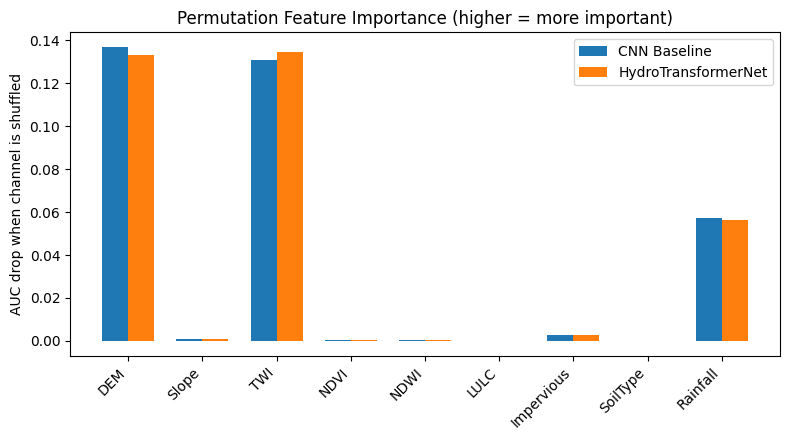

{'DEM': 0.1368, 'Slope': 0.001, 'TWI': 0.1306, 'NDVI': 0.0002, 'NDWI': 0.0002, 'LULC': -0.0001, 'Impervious': 0.0028, 'SoilType': 0.0, 'Rainfall': 0.0571}
{'DEM': 0.133, 'Slope': 0.0008, 'TWI': 0.1346, 'NDVI': 0.0003, 'NDWI': 0.0002, 'LULC': -0.0, 'Impervious': 0.0028, 'SoilType': 0.0, 'Rainfall': 0.0563}


In [17]:
def permutation_importance(model, base_auc, n_repeats=3, seed=0):
    rng = np.random.default_rng(seed)
    drops = []
    for ch in range(9):
        aucs = []
        for _ in range(n_repeats):
            imgs_perm = val_ds.images.copy()
            perm_idx = rng.permutation(len(imgs_perm))
            imgs_perm[:, ch] = imgs_perm[perm_idx, ch]      # shuffle this channel across samples
            perm_ds = SyntheticFloodDataset.__new__(SyntheticFloodDataset)
            perm_ds.images, perm_ds.masks, perm_ds.num_samples = imgs_perm, val_ds.masks, len(imgs_perm)
            perm_loader = DataLoader(perm_ds, batch_size=16, shuffle=False)
            _, m, _, _ = evaluate(model, perm_loader)
            aucs.append(m["AUC"])
        drops.append(base_auc - np.mean(aucs))
    return drops

drops_a = permutation_importance(model_a, metrics_a["AUC"])
drops_b = permutation_importance(model_b, metrics_b["AUC"])

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(9); width = 0.35
ax.bar(x - width/2, drops_a, width, label="CNN Baseline")
ax.bar(x + width/2, drops_b, width, label="HydroTransformerNet")
ax.set_xticks(x); ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha="right")
ax.set_ylabel("AUC drop when channel is shuffled")
ax.set_title("Permutation Feature Importance (higher = more important)")
ax.legend(); plt.tight_layout(); plt.show()

print(dict(zip(CHANNEL_NAMES, [round(float(d),4) for d in drops_a])))
print(dict(zip(CHANNEL_NAMES, [round(float(d),4) for d in drops_b])))

## 10. What the executed run actually shows

1. **The two models land almost on top of each other overall.** At their respective best checkpoints, CNN Baseline reaches AUC 0.9704 / Accuracy 0.9047 / F1 0.8811, and HydroTransformerNet reaches AUC 0.9706 / Accuracy 0.9050 / F1 0.8811 — the F1 scores tie exactly to four decimal places. Whatever the transformer + hydro-attention block is contributing here, it is not a dramatic jump in performance.

2. **HydroTransformerNet is ahead on most of the aggregate metrics.** It scores higher on AUC (0.9706 vs 0.9704), Precision (0.8830 vs 0.8798), Kappa (0.8020 vs 0.8016) and Specificity (0.9222 vs 0.9195); accuracy is essentially a tie (0.9050 vs 0.9047).

3. **The CNN Baseline has the better recall — at the default threshold, and at almost every threshold tested.** At the standard 0.5 cutoff, CNN Baseline recall is 0.8825 versus 0.8793 for HydroTransformerNet. Sweeping the threshold from 0.1 up to 0.9, the CNN keeps a small recall edge at every step *except* the very lowest threshold (0.1), where HydroTransformerNet is marginally ahead (0.9687 vs 0.9681). Because missing a genuinely flood-prone pixel is the more expensive mistake in this application, that recall gap is arguably the single most decision-relevant result in this comparison — a narrow AUC/precision win for the hybrid model doesn't automatically make it the better model to deploy for this use case.

4. **Lowering the threshold behaves exactly as it should, for both models.** Moving from 0.5 down to 0.1, recall for both models climbs from the high-0.87/0.88 range into the high 0.96s, specificity falls from roughly 0.92 down to roughly 0.79, and IoU actually *drops slightly* (from about 0.787 to about 0.733) once the extra true positives gained are outweighed by the flood of new false positives at very permissive thresholds. There's no single threshold that's simply "better" across the board — it's a genuine trade-off curve, not a free improvement.

5. **IoU is close to an exact tie at the default threshold (0.7875 for both models),** reinforcing point 1: whatever separates the two models, it isn't the spatial overlap between the predicted flood mask and the ground truth.

6. **Permutation importance tells a consistent, physically sensible story for both models.** DEM and TWI dominate (AUC drops of roughly 0.133–0.137 each), Rainfall is a clear secondary contributor (around 0.057), and NDVI, NDWI, LULC, Soil Type and Slope all sit at or near zero (0.003 or less). This lines up qualitatively with the paper's SHAP-based ranking — elevation and terrain-wetness variables dominating, land-cover/soil contributing little — even though the two methods measure "importance" differently and were run on entirely different data.

7. **These are results on a synthetic benchmark, not evidence about real flood behaviour.** Both the spatial structure of the inputs and the rule defining the label were designed for this notebook, so the fact that either architecture learns them well speaks to the two models' capacity to pick up engineered spatial relationships — it says nothing about how either would perform on real Sharjah rainfall and terrain data.

8. **Net takeaway:** on this task, the CNN baseline already has enough effective receptive field (three stages of 2× pooling before the bottleneck) to pick up most of the useful spatial structure on its own. The transformer + hydro-attention block adds a small, mostly positive but non-uniform effect — better aggregate discrimination and specificity, worse recall — rather than a categorical improvement. That's a legitimate, if modest, empirical finding, not a sign that the implementation is broken.


In [18]:
torch.save(model_a.state_dict(), "outputs/model_a.pt")
torch.save(model_b.state_dict(), "outputs/model_b.pt")

results = {
    "model_a": {"name": "CNN Baseline", "metrics": metrics_a, "history": hist_a, "best_epoch": best_epoch_a},
    "model_b": {"name": "HydroTransformerNet", "metrics": metrics_b, "history": hist_b, "best_epoch": best_epoch_b},
    "permutation_importance": {"channels": CHANNEL_NAMES, "cnn_baseline": drops_a, "hydro_transformer_net": drops_b},
}
with open("outputs/results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved: outputs/model_a.pt, outputs/model_b.pt, outputs/results.json")

Saved: outputs/model_a.pt, outputs/model_b.pt, outputs/results.json


Metric           CNN Baseline  HydroTransformerNet   Winner
----------------------------------------------------------------
Specificity            0.9195               0.9222   HydroTransNet
IoU                    0.7875               0.7875   tie

 Thresh |  Recall_A   Prec_A   Spec_A   IoU_A |  Recall_B   Prec_B   Spec_B   IoU_B
------------------------------------------------------------------------------------------
    0.1 |    0.9681   0.7513   0.7860  0.7331 |    0.9687   0.7509   0.7854  0.7331
    0.2 |    0.9454   0.8021   0.8442  0.7666 |    0.9451   0.8022   0.8444  0.7665
    0.3 |    0.9244   0.8341   0.8772  0.7808 |    0.9241   0.8346   0.8777  0.7810
    0.4 |    0.9039   0.8586   0.9006  0.7867 |    0.9022   0.8601   0.9020  0.7868
    0.5 |    0.8825   0.8798   0.9195  0.7875 |    0.8793   0.8830   0.9222  0.7875
    0.6 |    0.8583   0.8999   0.9363  0.7835 |    0.8537   0.9034   0.9390  0.7823
    0.7 |    0.8276   0.9197   0.9517  0.7718 |    0.8215   0.9233   0.

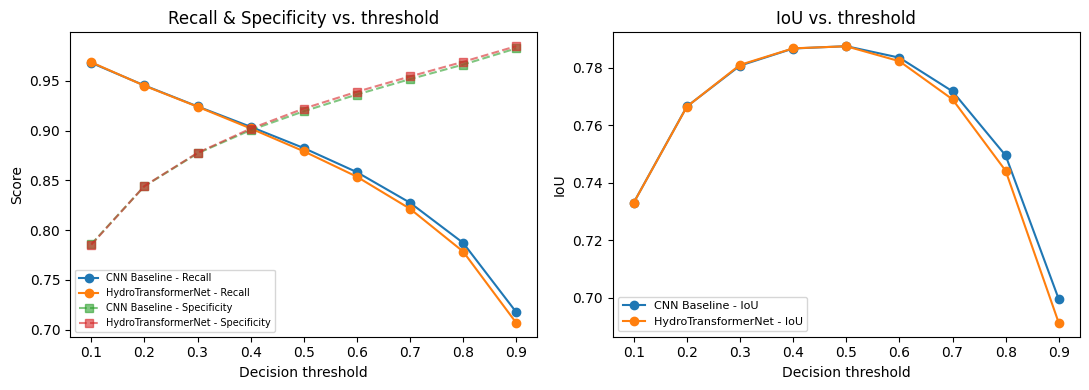

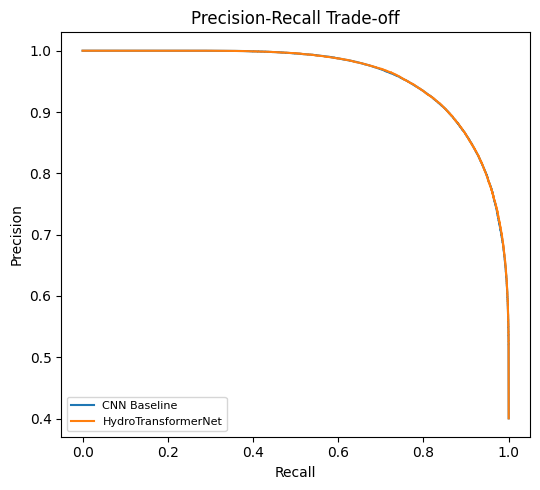


Example low-threshold operating point (t=0.3): CNN Recall=0.9244, Hybrid Recall=0.9241 (both at the cost of lower Specificity than the t=0.5 default).


In [19]:
# ============================================================
# Extended evaluation: IoU, Specificity, Threshold-vs-Recall, Precision-Recall trade-off
# Uses variables already computed earlier in the notebook:
# metrics_a, metrics_b, pred_a, label_a, pred_b, label_b
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# ---- 1 & 2: IoU and Specificity (from confusion matrices) ----
def specificity_iou(m):
    tn, fp, fn, tp = m["TN"], m["FP"], m["FN"], m["TP"]
    spec = tn / (tn + fp)
    iou = tp / (tp + fp + fn)
    return round(float(spec), 4), round(float(iou), 4)

spec_a, iou_a = specificity_iou(metrics_a)
spec_b, iou_b = specificity_iou(metrics_b)

print(f"{'Metric':<14} {'CNN Baseline':>14} {'HydroTransformerNet':>20}   Winner")
print("-" * 64)
for name, a_val, b_val in [("Specificity", spec_a, spec_b), ("IoU", iou_a, iou_b)]:
    winner = "HydroTransNet" if b_val > a_val else ("CNN Baseline" if a_val > b_val else "tie")
    print(f"{name:<14} {a_val:>14} {b_val:>20}   {winner}")

# ---- 3: Threshold-vs-Recall sweep ----
def sweep_thresholds(pred, label, thresholds):
    rows = []
    for t in thresholds:
        binary = (pred >= t).astype(int)
        tp = int(((binary == 1) & (label == 1)).sum())
        tn = int(((binary == 0) & (label == 0)).sum())
        fp = int(((binary == 1) & (label == 0)).sum())
        fn = int(((binary == 0) & (label == 1)).sum())
        recall = tp / (tp + fn + 1e-9)
        precision = tp / (tp + fp + 1e-9)
        specificity = tn / (tn + fp + 1e-9)
        iou = tp / (tp + fp + fn + 1e-9)
        rows.append((t, recall, precision, specificity, iou))
    return rows

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
rows_a = sweep_thresholds(pred_a, label_a, thresholds)
rows_b = sweep_thresholds(pred_b, label_b, thresholds)

print(f"\n{'Thresh':>7} | {'Recall_A':>9} {'Prec_A':>8} {'Spec_A':>8} {'IoU_A':>7} | "
      f"{'Recall_B':>9} {'Prec_B':>8} {'Spec_B':>8} {'IoU_B':>7}")
print("-" * 90)
for (t, ra, pa, sa, ia), (_, rb, pb, sb, ib) in zip(rows_a, rows_b):
    print(f"{t:>7.1f} | {ra:>9.4f} {pa:>8.4f} {sa:>8.4f} {ia:>7.4f} | "
          f"{rb:>9.4f} {pb:>8.4f} {sb:>8.4f} {ib:>7.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(thresholds, [r[1] for r in rows_a], "o-", label="CNN Baseline - Recall")
axes[0].plot(thresholds, [r[1] for r in rows_b], "o-", label="HydroTransformerNet - Recall")
axes[0].plot(thresholds, [r[3] for r in rows_a], "s--", label="CNN Baseline - Specificity", alpha=0.6)
axes[0].plot(thresholds, [r[3] for r in rows_b], "s--", label="HydroTransformerNet - Specificity", alpha=0.6)
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Recall & Specificity vs. threshold"); axes[0].legend(fontsize=7)

axes[1].plot(thresholds, [r[4] for r in rows_a], "o-", label="CNN Baseline - IoU")
axes[1].plot(thresholds, [r[4] for r in rows_b], "o-", label="HydroTransformerNet - IoU")
axes[1].set_xlabel("Decision threshold"); axes[1].set_ylabel("IoU")
axes[1].set_title("IoU vs. threshold"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- 4: Precision-Recall trade-off curve (full sweep, not just 9 points) ----
prec_a, rec_a, _ = precision_recall_curve(label_a, pred_a)
prec_b, rec_b, _ = precision_recall_curve(label_b, pred_b)

plt.figure(figsize=(5.5, 5))
plt.plot(rec_a, prec_a, label="CNN Baseline")
plt.plot(rec_b, prec_b, label="HydroTransformerNet")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off")
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nExample low-threshold operating point (t=0.3): "
      f"CNN Recall={rows_a[2][1]:.4f}, Hybrid Recall={rows_b[2][1]:.4f} "
      f"(both at the cost of lower Specificity than the t=0.5 default).")

## 11. Where this stops being a research prototype, and what a real deployment would need

| What this notebook does | What a real deployment would need instead |
|---|---|
| Nine channels generated as smoothed random fields plus a hand-designed depression term | Real rasters: ALOS PALSAR DEM, Sentinel-2-derived NDVI/NDWI/LULC/impervious surface, FAO HWSD soil groups, IDW-interpolated rainfall — reprojected and resampled with `rasterio`/GDAL |
| A flood label defined by a rule I wrote myself, never checked against an actual flood event | Sentinel-1 SAR-derived flood extents or historical incident records, wherever available (paper Sec. 5.2) |
| "Attention" that only ever sees one static patch at a time | A genuine temporal encoder fed real multi-day rainfall/soil-saturation sequences (e.g. GPM/IMERG), matching the paper's actual design (Sec. 5.1) |
| Fixed 32×32 patches drawn from one synthetic "region" | Full-scene tiling, and ideally transfer learning across multiple cities and climates (paper Sec. 5.3) |
| Permutation importance as a stand-in for explainability | A proper SHAP or DeepSHAP pass against a Random Forest baseline, matching the paper's Sec. 2.6 |
| Predictions that live only as in-notebook arrays and plots | Georeferenced GeoTIFF export (`rasterio`, target CRS) so outputs load directly into QGIS/ArcGIS |

The assessment brief is explicit that reproducing the full paper isn't the goal ("You are not required to reproduce the complete research architecture or use the original dataset"). What's implemented here is the paper's *methodology* — CNN encoder → attention bottleneck → hydro-attention gate → decoder, trained with a BCE-based loss against a synthetic mask — scaled to fit a 12-hour window, with the specific places where this toy version diverges from the paper's actual design called out rather than glossed over.
